In [ ]:
%matplotlib ipympl

import ipywidgets
import scipy.linalg as sci_lin
from helper import *


## Taylor plus LQR

We use a Taylor series expansion for the first 0.5s, and then we use an LQR to regulate for the remaining 1.5s.

In [ ]:
alpha = np.eye(3) * -1.8
A = np.array([[0, 1, 0], [0, 0, 1], [0, 0, 0]], dtype=float)
B = np.array([[0], [0], [1]], dtype=float)
Q = np.diag([1e0, 1e0, 1e0])
R = np.array([[1e-0]], dtype=float)
K, _, _ = ct.lqr(A - alpha, B, Q, R)
E = sci_lin.expm((A - B @ K) * spec.dt)

In [3]:
def diff(x, dt):
    return jnp.diff(x) / dt

def taylor_coeffs(hist, dt):
    assert hist.shape == (4,)
    a0 = hist[3]
    d = functools.partial(diff, dt=dt)
    a1 = d(hist[2:])
    a2 = d(d(hist[1:])) / 2
    a3 = d(d(d(hist))) / 6
    squee = jnp.squeeze
    return squee(a0), squee(a1), squee(a2), squee(a3)

def make_taylor_eval(hist, dt):
    a0, a1, a2, a3 = taylor_coeffs(hist, dt)

    def taylor_eval(x):
        return a0 + a1 * x + a2 * x**2 + a3 * x**3

    def taylor_evalp(x):
        a0, a1, a2, a3 = taylor_coeffs(hist, dt)
        f0 = a0 + a1 * x + a2 * x**2 + a3 * x**3
        f1 = a1 + 2 * a2 * x + 3 * a3 * x**2
        f2 = 2 * a2 + 6 * a3 * x
        return jnp.array([f0, f1, f2])

    return taylor_eval, taylor_evalp

def update_taylor(taylor_eval, dt, m, res):
    def taylor_fori(i, arr):
        t = i * dt
        arr = arr.at[i].set(taylor_eval(t))
        return arr

    res = jax.lax.fori_loop(0, m, taylor_fori, res)
    return res

def update_lqr(x0, E, m, res):
    def lqr_fori(i, carry):
        x0, arr = carry
        x1 = E @ x0
        arr = arr.at[i].set(x1[0])
        return x1, arr

    _, res = jax.lax.fori_loop(m, res.size, lqr_fori, (x0, res))
    return res
    
@functools.partial(jax.jit, static_argnames=["n"])
def pred_hist(n_taylor, n, dt, E, hist):
    taylor_eval, taylor_evalp = make_taylor_eval(hist, dt)
    x0 = taylor_evalp((n_taylor - 1) * dt)

    res = jnp.empty(n)
    res = update_taylor(taylor_eval, dt, n_taylor, res)
    res = update_lqr(x0, E, n_taylor, res)
    return res

mixed_pred = functools.partial(pred_hist, 4, spec.n, spec.dt, E)

(200,)


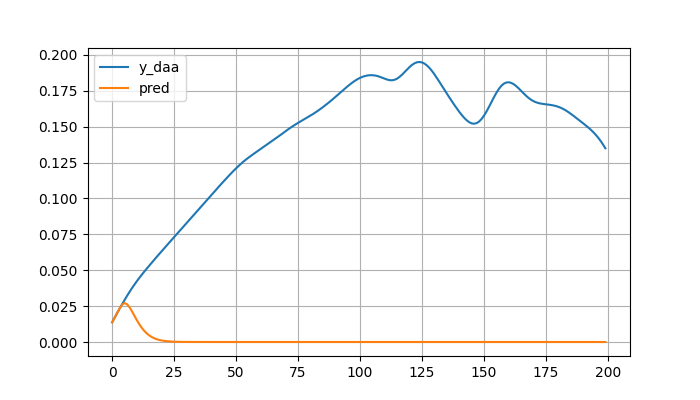

In [4]:
hist = y_vest[:4, 0]
y = mixed_pred(hist)
print(y.shape)
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.plot(y_vest[3: 3 + 200, 0], label="y_daa")
ax.plot(y, label="pred")
ax.grid()
ax.legend()

## quantitative analysis

In [5]:
lti_int, x_data, y_data, ctrl_data = get_data(2)

In [6]:
def pred_fun(hist, t, _):
    return mixed_pred(hist)

pred_err(pred_fun, y_data, 4)

Array(1067.51555419, dtype=float64)

In [7]:
def pred_fun_check(hist, t, idx):
    x0 = x_data[idx]
    _, y = lti_int(x0=x0, u=jnp.ones_like(t) * ctrl_data[idx])
    return y

pred_err(pred_fun_check, y_data, 2)

Array(1232.1260696, dtype=float64)

## visualize

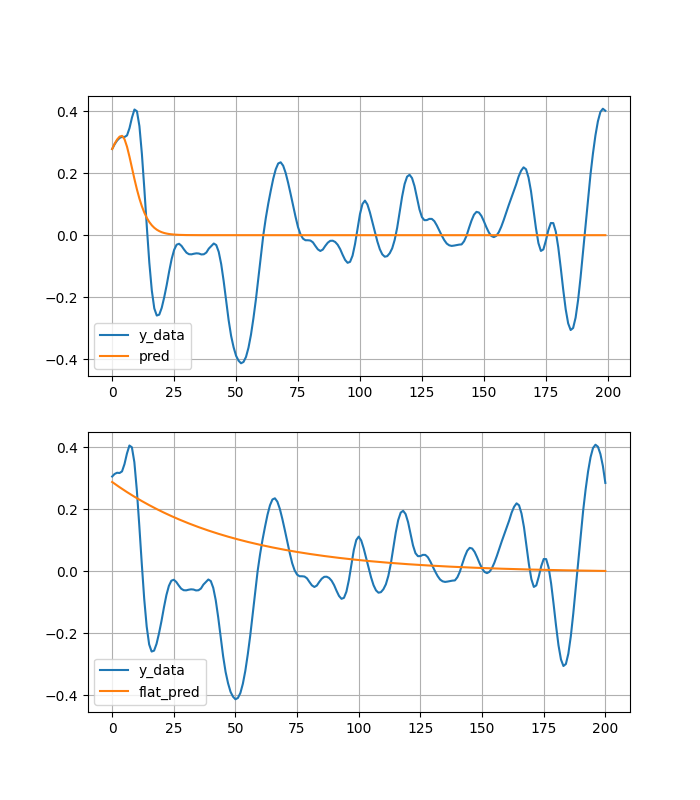

In [14]:
idx = 5010
t = np.linspace(0, 2.0, num=spec.n + 1, endpoint=True)

fig, axs = plt.subplots(2, 1, figsize=(7, 8))
axs[0].plot(y_data[idx - 1: idx + spec.n - 1], label="y_data")
axs[0].plot(pred_fun(y_data[idx - 4: idx], t, idx), label="pred")
axs[1].plot(y_data[idx + 1: idx + spec.n + 2], label="y_data")
axs[1].plot(pred_fun_check(y_data[idx - 1: idx + 1], t, idx), label="flat_pred")
for ax in axs:
    ax.grid()
    ax.legend()

interactive(children=(IntSlider(value=1000, description='idx', max=6000, min=4, step=20), Output()), _dom_clas…

<function __main__.update_idx(idx)>

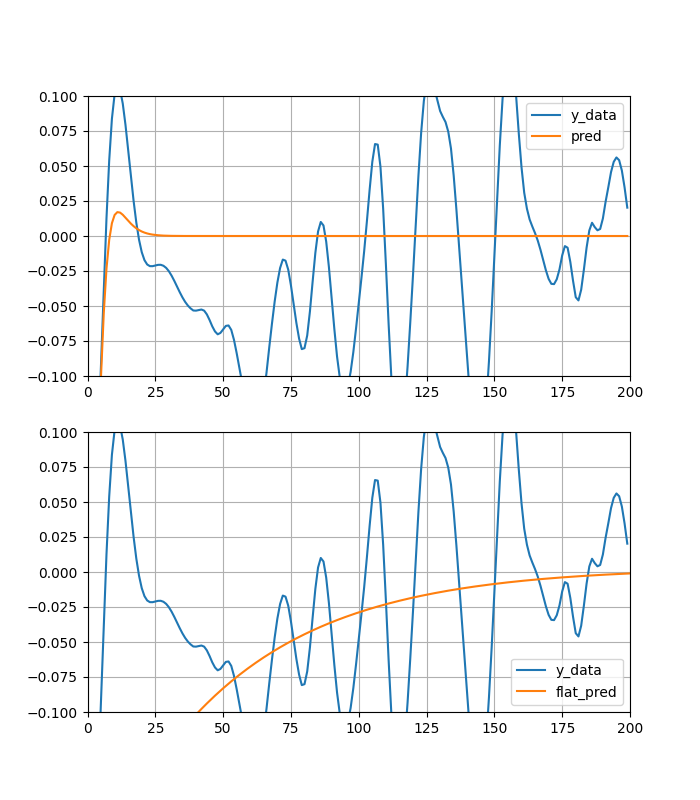

In [9]:
fig, axs = plt.subplots(2, 1, figsize=(7, 8))

idx = 1000
t = np.linspace(0, 2.0, num=spec.n + 1, endpoint=True)
line0, = axs[0].plot(y_data[idx: idx + spec.n], label="y_data")
line1, = axs[0].plot(pred_fun(y_data[idx - 3: idx + 1], t, idx), label="pred")
line2, = axs[1].plot(y_data[idx: idx + spec.n], label="y_data")
line3, = axs[1].plot(pred_fun_check(y_data[idx - 1: idx + 1], t, idx), label="flat_pred")
for ax in axs:
    ax.grid()
    ax.legend()
    ax.set_xlim(0, 200)
    ax.set_ylim(-0.1, 0.1)

def update_idx(idx):
    t = np.linspace(0, 2.0, num=spec.n + 1, endpoint=True)
    line0.set_ydata(y_data[idx: idx + spec.n])
    line1.set_ydata(pred_fun(y_data[idx - 3: idx + 1], t, idx))
    line2.set_ydata(y_data[idx: idx + spec.n])
    line3.set_ydata(pred_fun_check(y_data[idx - 1: idx + 1], t, idx))
    # for ax in axs:
    #     ax.grid()
    #     ax.legend()
    fig.canvas.draw_idle()
    
idx_slider = ipywidgets.widgets.IntSlider(value=idx, min=4, max=6000, step=20)
ipywidgets.interact(update_idx, idx=idx_slider)